# SPRINT 11: Visualización de datos 

## nivel 1

Conecta Python con MySQL Workbench i carga los datos de tu base de datos del Sprint4 para utilizar-la en todos los ejercicios.

Para cada ítem, crea una visualización adecuada según las variables especificadas. Interpreta los resultados según tus datos.

Recuerda: cuando selecciones las columnas, piensa siempre en el método que harás servir e incluye las que hagan falta para la función de visualización que quieras utilizar.

In [1]:
import pymysql
import pandas as pd
import string as str

conexion=pymysql.connect(host='localhost',user='root',password='1234', database='ventas')

cursor=conexion.cursor()

# realizo una selección para pasarlo a df y que sea el df con el que voy a trabajar el resto del sprint. 

cursor.execute('SELECT transaction_id, product_id ,company_id, company_name, c.country as company_country, c.website, card_id, expiring_date, ccd.status as credit_card_status, product_name, price as product_price, colour as product_color, weight as product_weight, warehouse_id,timestamp as transaction_timestamp, amount as transaction_amount, declined as transaction_declined,t.user_id,lat as transaction_lat,longitude as transaction_longitude,u.name as user_name,u.surname as user_surname,u.birth_date as user_birth_date,u.country as user_country,u.city as user_city FROM transactions as t JOIN companies as c ON t.business_id=c.company_id JOIN credit_cards as cc ON cc.id=t.card_id JOIN credit_cards_declinated as ccd ON ccd.id=cc.id JOIN users as u ON u.id=t.user_id JOIN products_transactions as pt ON pt.transaction_id = t.id JOIN products as p ON p.id=pt.product_id WHERE declined = 0;')
campos_seleccionados=cursor.fetchall()
nombre_columnas=[col[0] for col in cursor.description]
df_ventas=pd.DataFrame(campos_seleccionados,columns=nombre_columnas)


conexion.close()



In [2]:
df_ventas


,transaction_id,product_id,company_id,company_name,company_country,website,card_id,expiring_date,credit_card_status,product_name,...,transaction_amount,transaction_declined,user_id,transaction_lat,transaction_longitude,user_name,user_surname,user_birth_date,user_country,user_city
0,00043A49-2949-494B-A5DD-A5BAE3BB19DD,16,b-2458,Eget Tincidunt Dui Institute,Netherlands,https://wikipedia.org/user/110\r,CcS-9294,2025-02-25,active,the duel warden,...,395.43,0,4713,46.1999,1.43554,Gxnmjn,Fjycossj,1996-01-28,France,Marseille
1,00043A49-2949-494B-A5DD-A5BAE3BB19DD,26,b-2458,Eget Tincidunt Dui Institute,Netherlands,https://wikipedia.org/user/110\r,CcS-9294,2025-02-25,active,Stark Karstark,...,395.43,0,4713,46.1999,1.43554,Gxnmjn,Fjycossj,1996-01-28,France,Marseille
2,00043A49-2949-494B-A5DD-A5BAE3BB19DD,97,b-2458,Eget Tincidunt Dui Institute,Netherlands,https://wikipedia.org/user/110\r,CcS-9294,2025-02-25,active,jinn Winterfell,...,395.43,0,4713,46.1999,1.43554,Gxnmjn,Fjycossj,1996-01-28,France,Marseille
3,00043A49-2949-494B-A5DD-A5BAE3BB19DD,87,b-2458,Eget Tincidunt Dui Institute,Netherlands,https://wikipedia.org/user/110\r,CcS-9294,2025-02-25,active,sith Jade,...,395.43,0,4713,46.1999,1.43554,Gxnmjn,Fjycossj,1996-01-28,France,Marseille
4,000447FE-B650-4DCF-85DE-C7ED0EE1CAAD,66,b-2370,Non Justo Corp.,Sweden,https://baidu.com/en-us\r,CcS-5019,2025-03-27,active,mustafar jinn,...,155.63,0,438,41.5972,12.22180,Kvkvekp,Azofeyj,1957-08-16,Italy,Milan
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
252688,FFFC9E8D-27C7-4ADE-98F2-7533EF4DF126,16,b-2302,Nunc Interdum Incorporated,Germany,https://wikipedia.org/en-us\r,CcS-5589,2027-10-28,active,the duel warden,...,234.22,0,1008,59.3327,18.07530,Securp,Faofvqfy,1957-11-13,Sweden,Stockholm
252689,FFFC9E8D-27C7-4ADE-98F2-7533EF4DF126,49,b-2302,Nunc Interdum Incorporated,Germany,https://wikipedia.org/en-us\r,CcS-5589,2027-10-28,active,the giantsblood maester,...,234.22,0,1008,59.3327,18.07530,Securp,Faofvqfy,1957-11-13,Sweden,Stockholm
252690,FFFCF76D-ECF0-4985-A2D0-B2A7B75998FC,18,b-2250,Amet Nulla Donec Corporation,Italy,https://netflix.com/sub/cars\r,CcS-5261,2028-01-28,active,Karstark warden,...,148.91,0,680,52.0635,4.30862,Dfrled,Vilqcjdl,1969-12-18,Netherlands,The Hague
252691,FFFD31D6-9495-47CE-B54A-7DB8E1CC274B,48,b-2450,Turpis Company,Netherlands,https://instagram.com/sub\r,CcS-5684,2029-07-25,active,rock Renly in,...,74.54,0,1103,55.6384,-3.61660,Bmrgli,Tprvvmrc,1966-12-22,United Kingdom,Leeds


In [3]:
#  Consulto el tipo de datos de las columnas
df_ventas.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 252693 entries, 0 to 252692
Data columns (total 25 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   transaction_id         252693 non-null  object        
 1   product_id             252693 non-null  int64         
 2   company_id             252693 non-null  object        
 3   company_name           252693 non-null  object        
 4   company_country        252693 non-null  object        
 5   website                252693 non-null  object        
 6   card_id                252693 non-null  object        
 7   expiring_date          252693 non-null  object        
 8   credit_card_status     252693 non-null  object        
 9   product_name           252693 non-null  object        
 10  product_price          252693 non-null  float64       
 11  product_color          252693 non-null  object        
 12  product_weight         252693 non-null  floa

In [4]:
# Modifico el tipo de datos de product_id y de user_id a str para que en el dataframe quede claro que son categóricas
df_ventas[['user_id','product_id']]=df_ventas[['user_id','product_id']].astype('str')
df_ventas.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 252693 entries, 0 to 252692
Data columns (total 25 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   transaction_id         252693 non-null  object        
 1   product_id             252693 non-null  object        
 2   company_id             252693 non-null  object        
 3   company_name           252693 non-null  object        
 4   company_country        252693 non-null  object        
 5   website                252693 non-null  object        
 6   card_id                252693 non-null  object        
 7   expiring_date          252693 non-null  object        
 8   credit_card_status     252693 non-null  object        
 9   product_name           252693 non-null  object        
 10  product_price          252693 non-null  float64       
 11  product_color          252693 non-null  object        
 12  product_weight         252693 non-null  floa

In [5]:
# consulto que columnas son númericas y las que son categóricas:
df_columnas_numericas=df_ventas.select_dtypes(include=['number'])
df_columnas_categoricas=df_ventas.select_dtypes(exclude=['number'])

print('Las columnas numéricas son:')
print(', '.join(df_columnas_numericas.columns.tolist()))
print('Las columnas categóricas son: ')
print(', '.join(df_columnas_categoricas.columns.tolist()))



Las columnas numéricas son:
product_price, product_weight, transaction_amount, transaction_declined, transaction_lat, transaction_longitude
Las columnas categóricas son: 
transaction_id, product_id, company_id, company_name, company_country, website, card_id, expiring_date, credit_card_status, product_name, product_color, warehouse_id, transaction_timestamp, user_id, user_name, user_surname, user_birth_date, user_country, user_city


In [6]:
# Para crear las gráficas solicitadas importo las librerías que puedo necesitar
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px


### Una variable numérica.

In [7]:
# Preparo el dataframe para variable numérica
df_transacciones=df_ventas.groupby(['transaction_id']).agg(transaction_amount=('transaction_amount','first'))
df_transacciones

,transaction_amount
transaction_id,
00043A49-2949-494B-A5DD-A5BAE3BB19DD,395.43
000447FE-B650-4DCF-85DE-C7ED0EE1CAAD,155.63
00045D6B-ED2E-4F2F-8186-CEE074D875D0,326.01
000481C3-1C26-4FEF-83A0-4CD0EB004BBD,161.60
00051AA4-9CBE-4268-B070-C38062A1B3E2,148.91
...,...
FFF9E3CE-234E-408C-A8EF-F9CAD577224A,247.39
FFFB270D-F53A-4D5D-9666-E5307C53CC84,349.13
FFFC9E8D-27C7-4ADE-98F2-7533EF4DF126,234.22


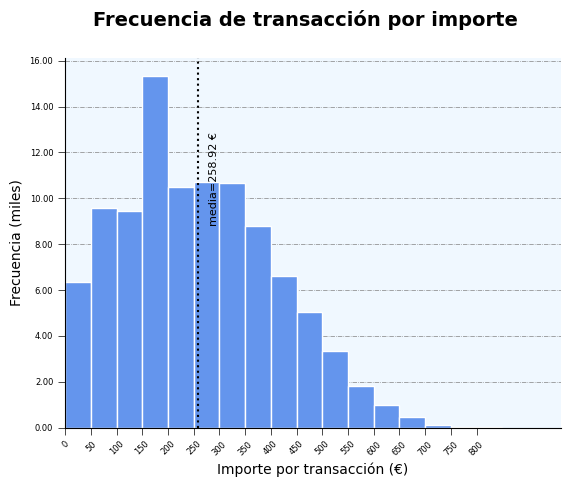

In [8]:
# Decido hacerlo con matplotlib para practicar con lenguaje matplotlib moderno
from matplotlib.ticker import MultipleLocator,AutoMinorLocator, StrMethodFormatter, FixedLocator, FuncFormatter
#  Se crea la figura y el axis
fig, ax = plt.subplots()

# DEFINIR LAS CARACTERÍSTICAS DE LA FIGURA Y LOS AXES
# Se modifica el color del fondo del gráfico: 
ax.set_facecolor("aliceblue")

# Se define el valor máximo para usarlo para determinar el número de bins en función del ancho deseado respecto el valor máximo:
valor_max=df_transacciones['transaction_amount'].max()


# Se define el tipo de gráfico que se va a dibujar en el axis. para determinar el ancho de las bins asociamos la generación de la figura a las tres variables 
# Declaramos la variable bins con np.arange(inicio,fin,cada 200)
bins=np.arange(0,valor_max,50)
# Al crear la gráfica determinamos las variables que la definen para luego extraer bin_edges y hacer que los ticks coincidan con los edge de las barras:
counts,bin_edges,patches= ax.hist(df_transacciones['transaction_amount'],bins=bins,edgecolor='white',facecolor='cornflowerblue')


# Se quitan los ejes superior y derecho
ax.spines.right.set_visible(False)
ax.spines.top.set_visible(False)

# Se define que queremos que se vea la rejilla(grid):
ax.set_axisbelow(True)# Para que quede detrás de las barras
ax.grid(linestyle='-.',linewidth=0.5,color='Grey', axis="y")



# Se rotula el gráfico y se reposiciona : 
plt.suptitle('Frecuencia de transacción por importe', y=0.98, x=0.5, fontweight='bold',fontsize=14)


# EJE DE LAS X:
# Se redefinen los límites del eje x:
ax.set_xlim(0,(valor_max + valor_max*0.1))
# Se define la etiqueta:
ax.set_xlabel(xlabel='Importe por transacción (€)')
# Se define el tick mayor 
ax.xaxis.set_major_locator(FixedLocator(bin_edges[:-1]))
# Parametrear los ticks de la x,se formatea la orientación y el tamaño de la letra
ax.tick_params(axis="x", labelrotation=45, labelsize=6, which='major',width=0.5, length=5, color='Black', labelcolor='Black')

# LINEA DE REFERENCIA VERTICAL:
# Se va a poner una línea de referencia con la media para que la tabla dé más información analítica: 
media=df_transacciones['transaction_amount'].mean().round(2)

ax.axvline(media,color='black',ls=':')

ax.text(x=media+20 ,y=ax.get_ylim()[1] * 0.8,s=f'media={media} €',fontsize=8,color='black',rotation=90, va='top')
# EJE DE LAS Y:

# Se define la etiqueta:
ax.set_ylabel(ylabel='Frecuencia (miles)')

# Parametrear los ticks de la x
ax.tick_params(axis="y",  labelsize=6, which='major',width=0.5, length=5)
# Cambiar el tipo de número que se va a representar: 
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x/1000:.02f}"))


plt.show()


En la visualización se observa que el mayor número de transacciones se concentra en el intervalo comprendido entre 150€ y 200€, que actúa como el rango más frecuente. 

La media de los importes de las transacciones se encuentra en un intervalo de frecuencia alta y, a partir de ese punto, se observa una disminución progresiva, en la que los importes  de más de 450€ son poco frecuentes.

Se observa una distribución asimétrica positiva de las frecuencias de las transacciones en función de su importe. 

### Dos variables numéricas.

In [9]:
from datetime import date
def calculo_edad(fecha):
    '''Calcula la edad en función de una fecha de nacimiento dada'''

    fecha_actual=date.today()
    edad=fecha_actual.year-fecha.year

    # Si aún no ha llegado el cumpleaños este año, restamos 1
    if (fecha_actual.month, fecha_actual.day) < (fecha.month, fecha.day):
        edad -= 1

    return edad


In [10]:
# por la alta cantidad de puntos (datos) no se puede representar a través de una scatterplot con lo que he obtado por usar un exbin

# Preparo el df que necesito:
df_edad_importe=df_ventas.groupby(['transaction_id']).agg({'transaction_amount':'first','user_birth_date':'first'}).reset_index()
df_edad_importe['user_birth_date']=pd.to_datetime(df_edad_importe['user_birth_date'])
# Transformar la fecha de nacimiento en edad:
df_edad_importe['user_edad']=df_edad_importe['user_birth_date'].apply(calculo_edad)

df_edad_importe



,transaction_id,transaction_amount,user_birth_date,user_edad
0,00043A49-2949-494B-A5DD-A5BAE3BB19DD,395.43,1996-01-28,29
1,000447FE-B650-4DCF-85DE-C7ED0EE1CAAD,155.63,1957-08-16,68
2,00045D6B-ED2E-4F2F-8186-CEE074D875D0,326.01,1995-09-04,30
3,000481C3-1C26-4FEF-83A0-4CD0EB004BBD,161.60,1969-02-19,56
4,00051AA4-9CBE-4268-B070-C38062A1B3E2,148.91,1961-02-08,64
...,...,...,...,...
99758,FFF9E3CE-234E-408C-A8EF-F9CAD577224A,247.39,1965-05-20,60
99759,FFFB270D-F53A-4D5D-9666-E5307C53CC84,349.13,1988-12-24,37
99760,FFFC9E8D-27C7-4ADE-98F2-7533EF4DF126,234.22,1957-11-13,68
99761,FFFCF76D-ECF0-4985-A2D0-B2A7B75998FC,148.91,1969-12-18,56


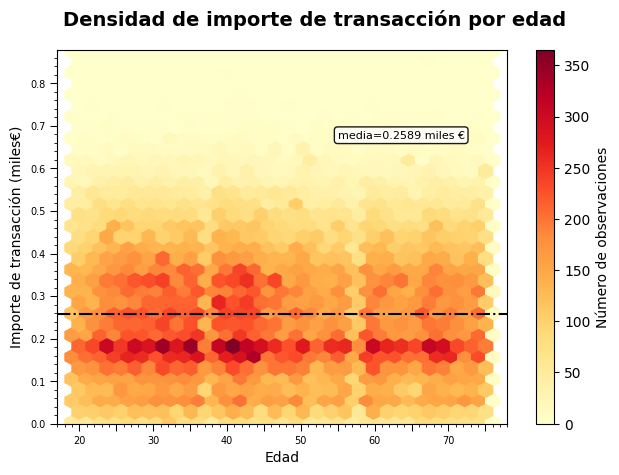

In [11]:
# por la gran cantidad de registros, siendo dos variables numéricas he optado usar la representación de densidad a través de hexbin con matplotlib
# Prueba con lenguaje matplotlib moderno
from matplotlib.ticker import MultipleLocator,AutoMinorLocator, StrMethodFormatter, FixedLocator, FuncFormatter
#  Se crea la figura y el axis
fig, ax = plt.subplots()
# Escojo Hexbin de matplotlib:
representacion=ax.hexbin(df_edad_importe['user_edad'],df_edad_importe['transaction_amount'],gridsize=30, cmap= 'YlOrRd')
plt.colorbar(representacion, label='Número de observaciones')
# Se rotula el gráfico y se reposiciona : 
plt.suptitle('Densidad de importe de transacción por edad', y=0.98, x=0.5,fontsize=14,fontweight='bold')
# # EJE DE LAS X:
valor_max=df_edad_importe['user_edad'].max()
valor_min=df_edad_importe['user_edad'].min()
# # Se redefinen los límites del eje x:
ax.set_xlim(valor_min-2,(valor_max +2))
# # Se define la etiqueta:
ax.set_xlabel(xlabel='Edad')
# # Se define el tick mayor 
ax.xaxis.set_major_locator(MultipleLocator(5))
# # Parametizar los ticks de la x,se parametiza la orientación y el tamaño de la letra
ax.tick_params(axis="x", labelsize=7, which='major',width=0.75, length=5, color='Black', labelcolor='Black')
# Etiqueta solo cada 10
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'{int(x)}' if x % 10 == 0 else ''))
# # Para asegurarse que que hay minor ticks se usa lo siguiente:
ax.minorticks_on()
# # Se definen los stikers menores a 2 espacios entre cada mayor
ax.xaxis.set_minor_locator(AutoMinorLocator(5))
# # EJE DE LAS Y:
# # Se redefinen los límites del eje y:
valor_ymax=df_edad_importe['transaction_amount'].max()
ax.set_ylim(0,(valor_ymax +2))
# # Se define la etiqueta:
ax.set_ylabel(ylabel='Importe de transacción (miles€)')
# # Parametrear los ticks de la x
ax.tick_params(axis="y",  labelsize=7, which='major',width=0.75, length=5)
# # Cambiar el tipo de número que se va a representar: 
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x/1000:.1f}"))
# # Se definen los stikers menores a 5 espacios entre cada mayor
ax.yaxis.set_minor_locator(AutoMinorLocator(5))
# # LINEA DE REFERENCIA HORIZONTAL:
# # Se va a poner una línea de referencia con la media para que la tabla dé más información analítica: 
media=df_transacciones['transaction_amount'].mean().round(2)
media_k=round(media/1000,4)
ax.axhline(media,color='black',ls='-.',lw=1.5)
ax.text(x=55,y=690,s=f'media={media_k} miles €',fontsize=8,color='black',va='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.9))
plt.tight_layout()
plt.show()


En este gráfico se observa un comportamiento similar al del histograma anterior en cuanto a la frecuencia de los importes de las transacciones, ya que, al analizar la degradación de los colores, se aprecia que los importes más frecuentes se concentran en los mismos rangos.

En cuanto a la edad, el comportamiento es bastante similar entre los distintos grupos, aunque se observa una mayor concentración de transacciones en los rangos de edad comprendidos entre 26 y 36 años y entre 39 y 46 años, que son los grupos que realizan un mayor número de transacciones.

### Una variable categoríca.

In [12]:
# barras: número de transacciones por país
df_paises=df_ventas.groupby(['transaction_id'])[['company_country']].first().reset_index()
df_paises


,transaction_id,company_country
0,00043A49-2949-494B-A5DD-A5BAE3BB19DD,Netherlands
1,000447FE-B650-4DCF-85DE-C7ED0EE1CAAD,Sweden
2,00045D6B-ED2E-4F2F-8186-CEE074D875D0,Ireland
3,000481C3-1C26-4FEF-83A0-4CD0EB004BBD,United States
4,00051AA4-9CBE-4268-B070-C38062A1B3E2,Sweden
...,...,...
99758,FFF9E3CE-234E-408C-A8EF-F9CAD577224A,Germany
99759,FFFB270D-F53A-4D5D-9666-E5307C53CC84,United Kingdom
99760,FFFC9E8D-27C7-4ADE-98F2-7533EF4DF126,Germany
99761,FFFCF76D-ECF0-4985-A2D0-B2A7B75998FC,Italy


In [13]:
conteo=df_paises['company_country'].value_counts().reset_index()
# Esto se debe hacer como buena práctica, para que salgan las barras ordenadas de mayor a menor
conteo=conteo.sort_values('count',ascending=False)
print(conteo)


   company_country  count
0           Sweden  16484
1      Netherlands  15033
2   United Kingdom  13754
3            Italy  13643
4          Germany  13269
5           France   4695
6    United States   4011
7          Belgium   3515
8           Norway   3011
9          Ireland   2651
10     New Zealand   2627
11       Australia   2544
12          Canada   2102
13           Spain   1511
14           China    913


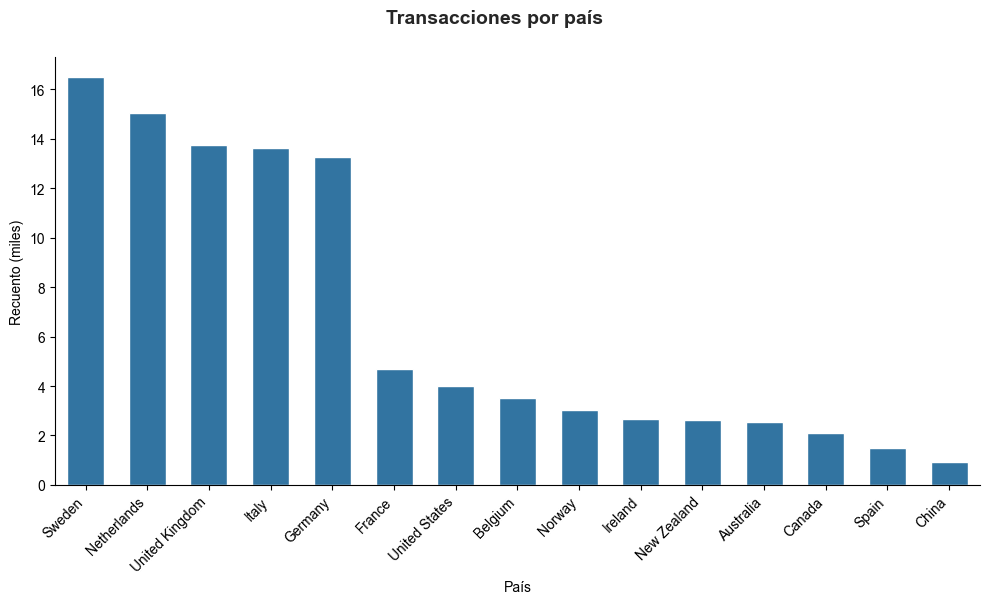

In [14]:
# Decido hacerlo con Seaborn 

# Aunque tenga su estilo propio si queremos hacer modificaciones concretas siempre hemos de iniciar el código con lo siguiente para definir la figura y los axes:
fig,ax=plt.subplots(figsize=(10,6))

# Poner uno de los estilos predeterminados de seaborn: 
sns.set_style("whitegrid") # es lo mimso que decir sns.set_theme(style='whitegrid')

# crear la gráfica que deseamos 
sns.barplot(data=conteo, x='company_country',y='count', width=0.6)

# Título
plt.suptitle('Transacciones por país', y=1,x=0.5, fontsize=14,fontweight='bold')

# Quitar las spines: 
# para quitar las que queremos usaremos: sns.despine(top=True, right=True, left=False, bottom=False)
sns.despine()

# Etiquetas de los ejes:
plt.xlabel('País')
plt.ylabel('Recuento (miles)')


# pero la solución corta en seaborn es tanto para la rotación como para la alineación de los ticks: 
plt.xticks(rotation=45, ha='right')
ax.yaxis.set_major_formatter(FuncFormatter(lambda x,_:f'{x/1000:.0f}' ))

plt.tight_layout()
plt.show()

La gráfica muestra la distribución de transacciones realizadas en cada país. Observamos que hay cinco países que destacan claramente en recuento de transacciones: Sweden, Netherlands, United Kingdom, Italy y Germany, apreciándose una brecha clara con el resto de países. En cambio, España y China son los países con menor número de transacciones.

### Una variable categórica y otra numérica.

In [15]:
#  Usaré como variable categórica año y como numérica amount
df_amount_año=df_ventas[['transaction_timestamp','transaction_amount']].drop_duplicates()
df_amount_año['año']=pd.to_datetime(df_amount_año['transaction_timestamp']).dt.year
df_amount_año

,transaction_timestamp,transaction_amount,año
0,2024-08-28 07:16:46,395.43,2024
4,2016-12-21 20:07:18,155.63,2016
7,2020-07-14 15:37:45,326.01,2020
11,2017-09-04 19:44:53,161.60,2017
12,2017-01-05 18:19:25,148.91,2017
...,...,...,...
252680,2022-12-17 20:57:55,247.39,2022
252684,2024-05-13 03:42:03,349.13,2024
252688,2019-10-30 02:31:37,234.22,2019
252690,2023-06-17 19:10:30,148.91,2023


In [16]:
df_ventas_anuales=df_amount_año.groupby(['año'])[['transaction_amount']].sum().reset_index().rename(columns={'transaction_amount':'Total ventas'})
df_ventas_anuales


,año,Total ventas
0,2015,2537626.57
1,2016,2551692.87
2,2017,2561608.52
3,2018,2539997.34
4,2019,2600809.41
5,2020,2602211.63
6,2021,2643099.45
7,2022,2635489.23
8,2023,2574960.75
9,2024,2582888.65


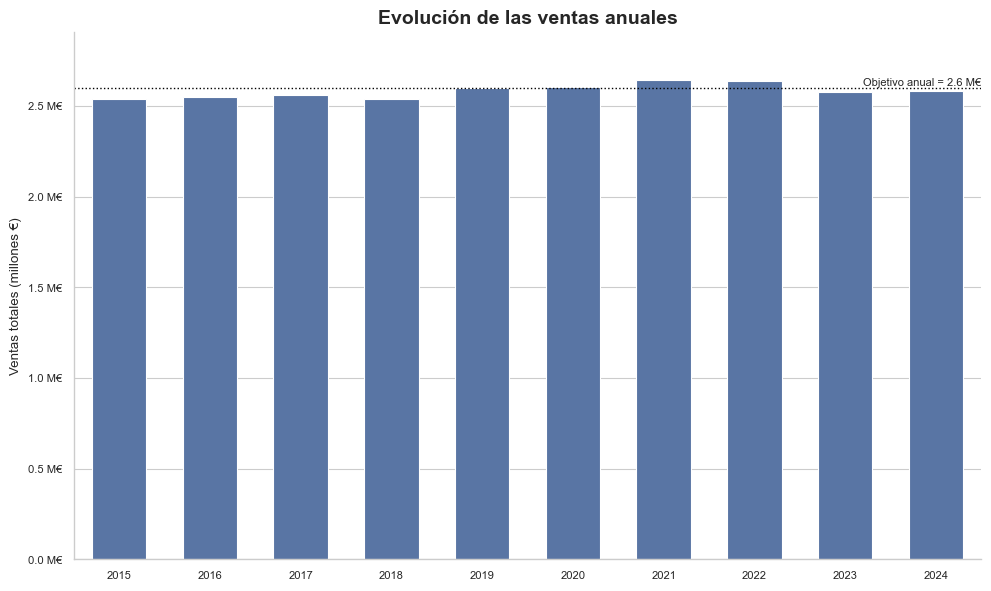

In [34]:
# Con seaborn

fig,ax=plt.subplots(figsize=(10,6))
sns.set_style("whitegrid") # es lo mimso que decir sns.set_theme(style='whitegrid')
sns.despine()

# definir el gráfico
sns.barplot(df_amount_año,x='año',y='transaction_amount', ax=ax, estimator=sum, errorbar=None, width=0.6)
#  Título
plt.title('Evolución de las ventas anuales',fontsize=14,fontweight='bold')

plt.ylabel('Ventas totales (millones €)')
ax.set_xlabel('')
# plt.xlabel('Año'); lo quito porque ya se sobreentiende y así quito ruido
# Determinar los límites de las y.
    # primero ver el valor_ymax
valor_ymax=df_amount_año.groupby(['año'])['transaction_amount'].sum().max()
ax.set_ylim(0,valor_ymax+valor_ymax*0.1)
ax.tick_params(labelsize=8)
ax.yaxis.set_major_formatter(FuncFormatter(lambda x,_: f'{x/1e6:.1f} M€'))
# Se crea la línea horizontal de objetivo anual
objetivo_anual=2600000
ax.axhline(objetivo_anual,color='black',ls=':', lw=1)
ax.text(ax.get_xlim()[1],objetivo_anual,'Objetivo anual = 2.6 M€', fontsize=8, ha='right', va='bottom')

plt.tight_layout()
plt.show()



La presente visualización permite analizar la evolución de las ventas anuales a lo largo del periodo considerado, así como su comparación con el objetivo anual establecido.

Se observa un crecimiento sostenido de las ventas hasta el año 2021, en el que se alcanza el máximo nivel de ventas registrado. A partir de dicho año, se identifica una tendencia descendente, si bien en 2024 se aprecia un ligero repunte.

En relación con el cumplimiento del objetivo anual, este únicamente se alcanza en los años 2020 y 2021.


### Dos variables categóricas.

In [18]:
# Crosstab, y heatmap
import string as str


df_web_company=df_ventas[['website','company_country']].reset_index(drop=True).rename(columns={'company_country':'País'})

df_web_company['dominio']=df_web_company['website'].str.extract(r'https://([^./]+)')
df_web_company['dominio']=df_web_company['dominio'].str.capitalize()
df_web_company=df_web_company[['País','dominio']].drop_duplicates().reset_index(drop=True)

df_web_company_cross=pd.crosstab(df_web_company['dominio'],df_web_company['País'])

df_web_company


,País,dominio
0,Netherlands,Wikipedia
1,Sweden,Baidu
2,Ireland,Whatsapp
3,United States,Pinterest
4,Sweden,Instagram
...,...,...
73,New Zealand,Twitter
74,Canada,Baidu
75,New Zealand,Reddit
76,United States,Netflix


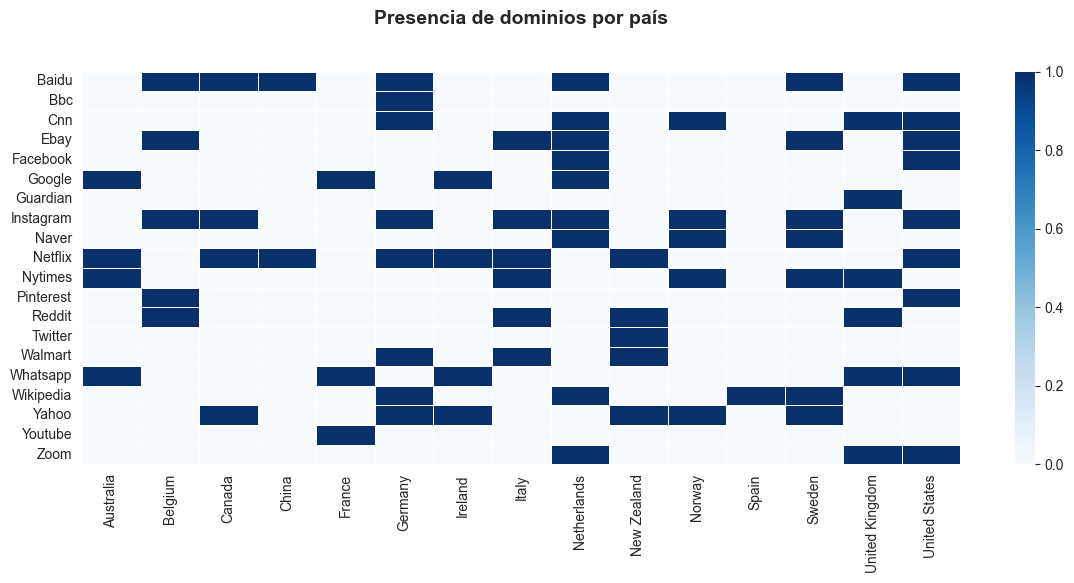

In [ ]:
# Realizo la visualizción con seaborn seleccionando el tipo de representación heatmap

plt.figure(figsize=(12,6))
sns.heatmap(df_web_company_cross,cmap='Blues',cbar=True,linewidths=0.5)
plt.title('Presencia de dominios por país',y=1.1,fontsize=14,fontweight='bold')
plt.xlabel('')
plt.ylabel('')
plt.tight_layout()
plt.show()


La visualización muestra la presencia de distintos dominios web en los países analizados mediante un mapa de calor, lo que permite examinar la relación entre ambas variables categóricas. Esta representación facilita identificar tanto la distribución de los dominios por país como el número de dominios presentes en cada uno de ellos.

Se observa que algunos dominios presentan una amplia presencia internacional, como Netflix e Instagram, mientras que otros muestran una presencia más limitada, como BBC o Twiter.

Asimismo, se identifican diferencias entre países en cuanto a la diversidad de dominios presentes. Alemania, Países Bajos y Estados Unidos destacan por concentrar un mayor número de dominios, mientras que España presenta una presencia reducida, limitada en este caso al dominio Wikipedia.

### Tres variables combinadas.

In [20]:


df_web_country_company_amount=df_ventas.groupby(['transaction_id'])[['company_country','company_name','website','transaction_amount']].first().reset_index()
df_web_country_company_amount['dominio']=df_web_country_company_amount['website'].str.extract(r'https://([^./]+)')
df_web_country_company_amount['dominio']=df_web_country_company_amount['dominio'].str.capitalize()

df_treemap_web_country_company_amount=df_web_country_company_amount.groupby(['dominio','company_country']).agg(total_ventas=('transaction_amount','sum'),num_transacciones=('transaction_amount','count'), num_companies=('company_name','nunique')).reset_index()

df_treemap_compañías_dominio=df_treemap_web_country_company_amount.groupby(['dominio']).agg(num_companies_dominio=('num_companies','sum')).reset_index()
df_treemap_web_country_company_amount_numcompany=pd.merge(df_treemap_web_country_company_amount,df_treemap_compañías_dominio,on='dominio').rename(columns={'dominio':'Dominio web','company_country':'País','total_ventas':'Total ventas','num_transacciones':'Número de transacciones','num_companies':'Número de compañías','num_companies_dominio':'Número de compañías por dominio'})
df_treemap_web_country_company_amount_numcompany


,Dominio web,País,Total ventas,Número de transacciones,Número de compañías,Número de compañías por dominio
0,Baidu,Belgium,126204.68,472,1,8
1,Baidu,Canada,97519.03,378,1,8
2,Baidu,China,125928.45,484,1,8
3,Baidu,Germany,384911.13,1518,1,8
4,Baidu,Netherlands,394134.81,1540,1,8
...,...,...,...,...,...,...
73,Yahoo,Sweden,379516.13,1447,1,6
74,Youtube,France,404569.33,1564,1,1
75,Zoom,Netherlands,775884.24,2961,2,4
76,Zoom,United Kingdom,385058.33,1490,1,4


In [21]:

fig=px.treemap(df_treemap_web_country_company_amount_numcompany,path=['Dominio web', 'País'],values='Total ventas',title='<b>Distribución facturación por dominios web y paises que usan el dominio<b>',hover_data={'Número de transacciones':True,'Número de compañías':True,'Número de compañías por dominio':True})

fig.update_layout(title={'x':0.5,'xanchor':'center','font':{'size':14,'color':'black'}})

fig.update_traces(textinfo='label+value',insidetextfont=dict(size=12))


fig.show()

En el treemap se representa la proporción de ventas por dominio web que proporciona clientes a las empresas que hay en los diferentes países. Las etiquetas descriptivas sobre país nos amplían información sobre ventas totales realizadas a través del dominio y la aprotación de las ventas a través de ese canal por país, así como, el número de compañías por país que utilizan ese canal y el número total de compañias que usan el dominio como herramienta de venta.

Podemos observar que el canal con más ventas es Netflix seguido de Instagram. Podemos observar que Twitter es el dominio que menos ventas proporciona.

Sobre los canales que proporcionan mayor total de ventas vemos que son los dominios que más represatación por país y compañías hay.

### Crear un Pairplot.

In [22]:
# Prepara df con precio producto y peso 

df_precio_peso=df_ventas[['product_id','product_price','product_weight']].drop_duplicates().reset_index(drop=True)

df_precio_peso



,product_id,product_price,product_weight
0,16,180.91,3.0
1,26,53.01,2.0
2,97,65.25,1.0
3,87,96.26,1.5
4,66,2.12,0.8
...,...,...,...
95,59,114.77,2.7
96,60,68.38,2.1
97,77,150.50,3.2
98,86,189.21,2.0


In [ ]:
#  Se prepara df para unidades vendidas

df_items_vendidos=df_ventas['product_id'].value_counts().sort_index().reset_index().rename(columns={'count':'num_prod_vendidos'})
df_items_vendidos

,product_id,num_prod_vendidos
0,1,2467
1,10,2561
2,100,2507
3,11,2559
4,12,2548
...,...,...
95,95,2516
96,96,2500
97,97,2520
98,98,2557


In [ ]:
# Se consigue el df final para usar en la visualización uniendo los dos df anteriores:
df_precio_peso_items_vendidos=pd.merge(df_precio_peso,df_items_vendidos, on='product_id').rename(columns={'product_price':'Precio (€)','product_weight':'Peso (kg)','num_prod_vendidos':'Unidades vendidas'})
df_precio_peso_items_vendidos=df_precio_peso_items_vendidos.set_index('product_id').sort_index()
df_precio_peso_items_vendidos

,Precio (€),Peso (kg),Unidades vendidas
product_id,,,
1,161.11,1.0,2467
10,119.52,2.4,2561
100,40.43,3.0,2507
11,49.70,2.7,2559
12,181.60,2.1,2548
...,...,...,...
95,6.90,2.7,2516
96,20.92,2.1,2500
97,65.25,1.0,2520


In [25]:
correlacion_df_precio_peso_items_vendidos=df_precio_peso_items_vendidos[['Unidades vendidas','Peso (kg)']].corr()
correlacion_df_precio_peso_items_vendidos


,Unidades vendidas,Peso (kg)
Unidades vendidas,1.000000,0.205357
Peso (kg),0.205357,1.000000


In [26]:

correlacion_df_precio_peso_items_vendidos2=df_precio_peso_items_vendidos[['Precio (€)','Peso (kg)']].corr()
correlacion_df_precio_peso_items_vendidos2


,Precio (€),Peso (kg)
Precio (€),1.000000,0.105431
Peso (kg),0.105431,1.000000


In [27]:
correlacion_df_precio_peso_items_vendidos3=df_precio_peso_items_vendidos[['Precio (€)','Unidades vendidas']].corr()
correlacion_df_precio_peso_items_vendidos3


,Precio (€),Unidades vendidas
Precio (€),1.000000,0.193099
Unidades vendidas,0.193099,1.000000


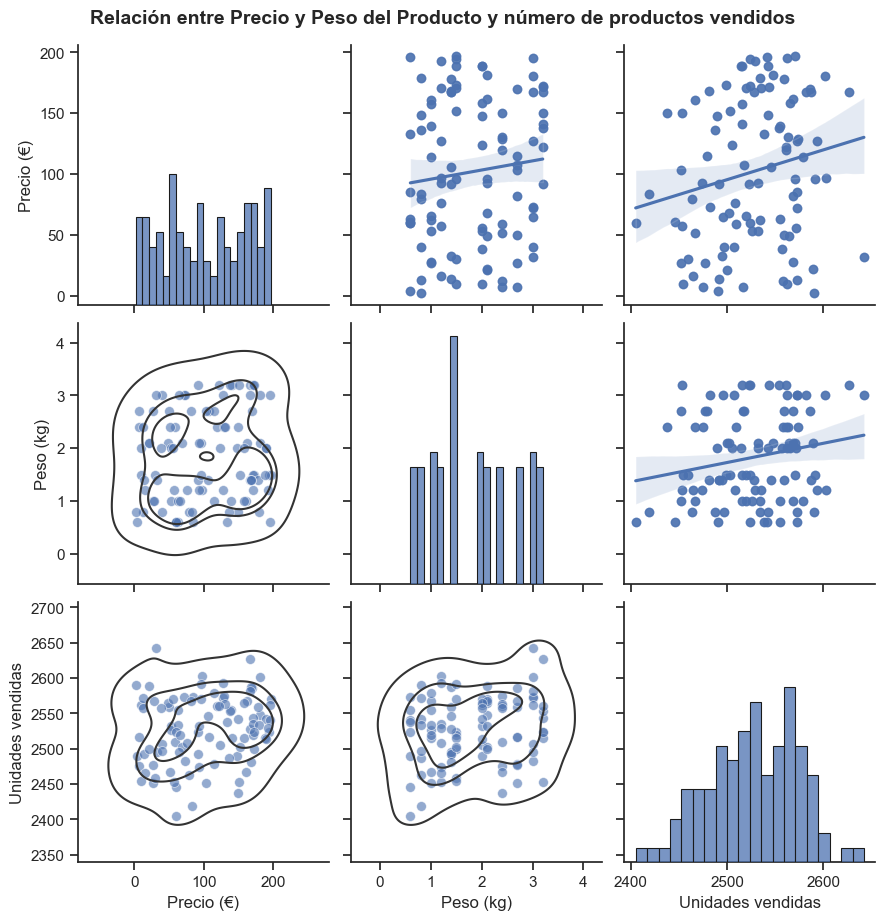

In [ ]:


sns.set_theme(style="ticks")

axs=sns.pairplot(df_precio_peso_items_vendidos,diag_kind="hist",plot_kws=dict(s=50, alpha=0.6, edgecolor="white"),diag_kws=dict(bins=20,edgecolor="k"),height=3)
axs.map_lower(sns.kdeplot, levels=4, color=".2")
axs.map_upper(sns.regplot)

plt.suptitle("Relación entre Precio y Peso del Producto y número de productos vendidos",fontsize=14,y=1.02,fontweight='bold')

plt.show()




La visualización presenta la relación existente entre el precio del producto, número de productos vendidos y el peso del producto. Está representada con un pairplot que realiza la comparación a pares de las variables.
En la diagonal podemos ver que:
* Los precios de los productos se encuentran entre 0 y 200€ con una distribución de precios heterogénea. Se destaca la mayor frecuencia de precios comprendidos entre 60 y 70 € seguidos de los productos con un precio superior a 190€. Los precios de los productos menos presente en el listado de precios aon los comprendidos entre 50 y 60€ y los comprendidos entre 110 y 120€.
* La distribución de pesos de los productos tienen una frecuencia similar, salvo los pesos de 1.3 a 1.4kg que representan el mayor número de apariciones. Por otro lado, podemos observar que existen huecos de rango de pesos sin productos asignados.

* En cuanto al número de ventas por producto observamos que están comprendidas entre 2400 unidades y 2650 unidades. Se observa que la mayor concentración de número de ventas de unidades se concentra entre 2450 y 2600 unidades.

Sobre las relaciones que se aprecian entre variables:
* Que la representación de puntos, tanto entre número de productos vendidos y peso del producto, como la relación entre número de productos vendidos y precio del producto, y como peso del producto con precio del producto, es muy dispersa no apreciándose una relación clara entre las diferentes variables. Se observa la correlación positiva de pearson con tendencia a la  horizontal, indica una relación muy débil. 

* Las densidades Kernel refuerzan esta observación, mostrando zonas de mayor concentración de datos, pero sin patrones definidos que indiquen una dependencia clara entre las variables.


## Nivel 2

### Representa la correlación de algunas variables e interpreta los resultados según tus datos.

In [29]:
# forma mas corta: 
regex_dominio = r'https://([^./]+)'

df_web_country_company_amount_web = (df_ventas[['company_country', 'company_name', 'transaction_amount', 'website']].drop_duplicates()
        .assign(dominio=lambda df: df['website'].str.extract(regex_dominio, expand=False))
        .groupby('company_country').agg(total_amount=('transaction_amount', 'sum'),num_companies=('company_name', 'nunique'),num_website=('dominio', 'nunique'))
        .reset_index()).rename(columns={'num_companies':'Total compañías','total_amount':'Total ventas (€)','num_website':'Total dominios'})

df_web_country_company_amount_web


,company_country,Total ventas (€),Total compañías,Total dominios
0,Australia,641936.53,6,4
1,Belgium,874470.43,8,5
2,Canada,511461.73,5,4
3,China,216630.18,2,2
4,France,1100206.54,3,3
5,Germany,2852947.50,8,8
6,Ireland,650888.04,6,4
7,Italy,3185629.44,9,6
8,Netherlands,3527381.96,10,9
9,New Zealand,646343.70,6,5


In [30]:
df_corr_companies_amount_web=df_web_country_company_amount_web[['Total compañías','Total ventas (€)','Total dominios']].corr()
df_corr_companies_amount_web

,Total compañías,Total ventas (€),Total dominios
Total compañías,1.000000,0.762613,0.892013
Total ventas (€),0.762613,1.000000,0.683491
Total dominios,0.892013,0.683491,1.000000


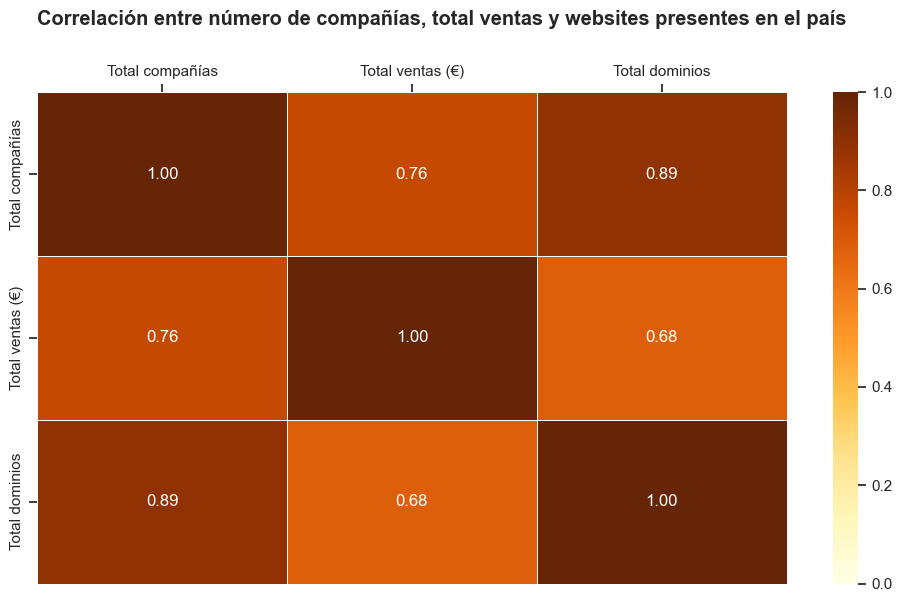

In [31]:
# Representación a través de heatmap:

fig,ax=plt.subplots(figsize=(10,6))
ax=sns.heatmap(df_corr_companies_amount_web,vmin=0,vmax=1,annot=True,fmt=".2f",linewidth=0.5,cmap="YlOrBr")
plt.suptitle('Correlación entre número de compañías, total ventas y websites presentes en el país',y=1,x=0.45,fontweight='bold')
# ax.set(xlabel="variables numéricas", ylabel="variables numéricas")
ax.xaxis.set_label_position('top')
ax.xaxis.tick_top()
plt.tight_layout()
plt.show()

En los tres casos se observa una correlación de Pearson positiva. 
* La correlación entre el número de compañías y el número de websites por país es muy fuerte (r = 0.89).
* La correlación entre el número de compañías y el valor total de las ventas por país es fuerte (r = 0.76).
* La correlación entre el número de websites y el total de ventas por país es positiva y fuerte, aunque ligeramente menor (r = 0.68).

Observamos una correlación leve positiva entre total de ventas del país y numero de websites

### Implementa un joinplot para explorar la relación entre dos variables e interpreta los resultados según tus datos.

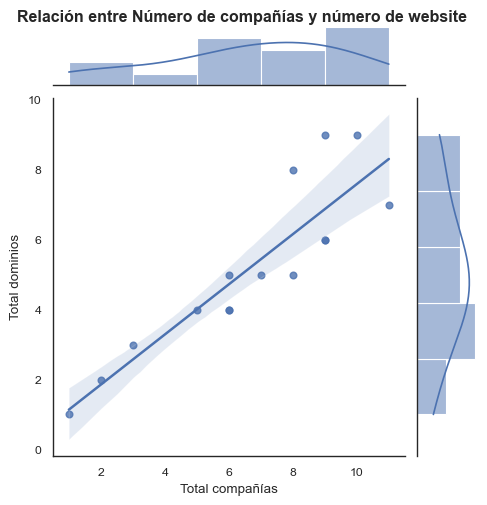

In [32]:
sns.set_theme(style="white", context="paper")

sns.jointplot(x='Total compañías', y='Total dominios', data=df_web_country_company_amount_web,kind='reg', height=5)

plt.suptitle('Relación entre Número de compañías y número de website',fontweight='bold', y=1)

plt.show()


La visualización indica que existe una relación lineal positiva clara entre el número de compañías y el número de websites por país: los países con más compañías tienden a tener también más websites. Las distribuciones marginales que se muestran a través de boxplot refuerzan esta lectura mostrando concentraciones en rangos medios y una dispersión moderada.


## Nivel 3

### Transfiere todas las visualizaciones del nivel 1 a Power BI utilizando scripts de Python. 

Hecho en power BI